In [1]:
import sys
import os
# Get the absolute path to the project root
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
# Add it to sys.path
sys.path.append(project_root)
os.chdir(project_root)

In [2]:
import numpy as np
from bimpcc.dataset import get_dataset
from bimpcc.models.tvqregularized_sinbeta_sparse import TVqRegularized
from bimpcc.models.tvq_denoising_sinbeta import TVDenoisingMPCC
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from bimpcc.utils import generate_2D_gradient_matrices

In [3]:
def plot_experiment(true,noisy,u, alpha):
    
    fig,ax = plt.subplots(1,3,figsize=(14,4))
    ax[0].imshow(true,cmap='gray')
    ax[0].set_title('True Image')
    ax[0].axis('off')
    ax[1].imshow(noisy,cmap='gray')
    ax[1].set_title('Noisy Image\nPSNR: {:.4f}'.format(psnr(true,noisy)))
    ax[1].axis('off')
    ax[2].imshow(u,cmap='gray')
    ax[2].set_title(f'Reconstructed Image\nPSNR: {psnr(true,u):.4f}\n alpha = {alpha}')
    # ax[2].set_xlabel('alpha = {}'.format(alpha))
    ax[2].axis('off')

    plt.show()

In [4]:
scale = 30

In [5]:
dataset = get_dataset("guacamayo",scale=scale, random_state=1)
true, noisy = dataset.get_training_data()

(np.float64(-0.5), np.float64(29.5), np.float64(29.5), np.float64(-0.5))

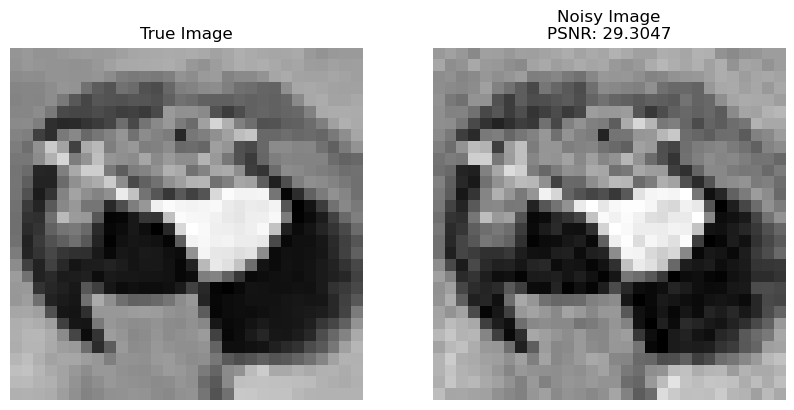

In [6]:
fig,ax = plt.subplots(1,2,figsize=(10,5))
ax[0].imshow(true,cmap='gray')
ax[0].set_title('True Image')
ax[0].axis('off')
ax[1].imshow(noisy,cmap='gray')
ax[1].set_title('Noisy Image\nPSNR: {:.4f}'.format(psnr(true,noisy)))
ax[1].axis('off')

In [7]:
model = TVqRegularized(true, noisy, epsilon=1e-3, q_param=0.72)

In [8]:
res,x_opt,fun_opt = model.solve(max_iter=3000,tol=1e-4,print_level=5)

[100.]
[100.]
[100.]
[99.9926869]
[98.48220078]
[98.00659736]
[98.16084732]
[98.2178889]
[98.20243388]
[98.17212375]
[98.18146476]
[98.17978816]
[98.18121747]
[98.20796213]
[98.51151789]
[98.81571385]
[99.10309502]
[99.1034303]
[99.25871187]
[109.92434615]
[105.28972867]
[104.90763877]
[86.4530364]
[104.90763877]
[104.90241196]
[115.78668538]
[115.88942051]
[111.53217604]
[139.2535183]
[123.61257747]
[116.31502545]
[115.07159369]
[115.67850418]
[115.7949316]
[115.66799559]
[115.57974927]
[115.44081954]
[115.43958346]
[115.43506857]
[115.41315886]
[115.39233889]
[115.36966494]
[115.36985612]
[115.36541707]
[115.36242433]
[115.35800535]
[115.35814492]
[115.35510855]
[114.59231714]
[114.35707016]
[113.90869459]
[114.13120832]
[114.161079]
[114.12990956]
[114.14527586]
[114.14291437]
[114.1458199]
[114.14580686]
[114.14712719]
[114.14615757]
[114.14735982]
[114.14660454]
[114.14740034]
[114.14684341]
[114.14738682]
[114.1470153]
[114.14742479]
[114.14723118]
[114.14749963]
[114.14747336]


In [9]:
print(open("ipopt.log", "r", encoding="utf-8", errors="ignore").read()[:5000])


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.1.

Number of nonzeros in equality constraint Jacobian...:    42960
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:     2641
                     variables with only lower bounds:      901
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:     2640
Total number of inequality c

In [10]:
u, q, alpha = model.objective_func.parse_vars(x_opt)

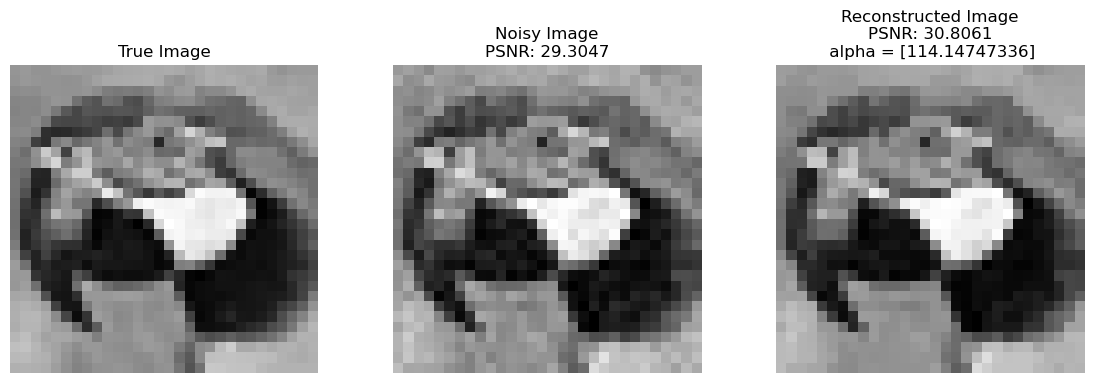

In [11]:
u_scaled = u.reshape((scale,scale))
plot_experiment(true,noisy,u_scaled,alpha)

In [12]:
# x0_q = None
# #vect_q = [0.99, 0.9, 0.8, 0.75, 0.7, 0.65, 0.6, 0.55, 0.5]
# vect_q = [0.99, 0.9]
# for i in range(len(vect_q)):
#     model = TVqRegularized(true, noisy, epsilon = 1e-3, x0 = x0_q, q_param = vect_q[i])
#     res,x_opt,fun_opt = model.solve(max_iter = 3000,tol = 1e-4,print_level = 5)
#     u, q, alpha = model.objective_func.parse_vars(x_opt)
#     x0_q = np.concatenate((u, q, alpha))

# u_scaled = u.reshape((scale,scale))
# plot_experiment(true,noisy,u_scaled,alpha)
    

In [13]:
Kx, Ky, K = generate_2D_gradient_matrices(scale)

In [14]:
m = q.flatten().size
n = m // 2

Ku = K @ u.flatten()
V = Ku.reshape(2, -1).T
normKu = np.apply_along_axis(np.linalg.norm, axis=1, arr=V)
Q = q.reshape(2,-1).T
normQ = np.apply_along_axis(np.linalg.norm, axis=1, arr=Q)
r0 = normKu
delta0 = normQ

In [15]:
Kxu = Ku[:n]  # Primeras n componentes
Kyu = Ku[n:]  # Últimas n componentes
qx = q[:n]  # Primeras n componentes
qy = q[n:]  # Últimas n componentes
epsilon = 1e-10  

# Condiciones para calcular theta según los casos dados
theta0 = np.zeros(n)  # Inicializamos theta0

# Caso 1: r_i ≠ 0
mask_r_nonzero = r0 > epsilon
theta0[mask_r_nonzero] = np.arccos(Kxu[mask_r_nonzero] / r0[mask_r_nonzero])
theta0[mask_r_nonzero & (Kyu < 0)] *= -1  # Si Ky^i u < 0, negamos theta0

# Caso 2: r_i = 0 y delta_i ≠ 0
mask_r_zero_delta_nonzero = (r0 <= epsilon) & (delta0 > epsilon)
theta0[mask_r_zero_delta_nonzero] = np.arccos(qx[mask_r_zero_delta_nonzero] / delta0[mask_r_zero_delta_nonzero])
theta0[mask_r_zero_delta_nonzero & (qy < 0)] *= -1  # Si qy^i < 0, negamos theta0

# Caso 3: r_i = 0 y delta_i = 0 (theta0 indefinido)
mask_r_zero_delta_zero = (r0 <= epsilon) & (delta0 <= epsilon)
theta0[mask_r_zero_delta_zero] = 0

In [16]:
x0_mpcc = np.concatenate((u.flatten(),q.flatten(),r0,delta0,theta0,alpha))
# print(x0_mpcc)

In [17]:
mpcc_model = TVDenoisingMPCC(true, noisy, x0=x0_mpcc, epsilon=1e-3, q_param = 0.99)

In [18]:
res_mpcc, x_opt_mpcc, fun_opt_mpcc, history = mpcc_model.solve(t_init = 0.001, max_iter=100,tol=1e-5,print_level=5,verbose=True)

Iter   Termination_status            Objective      MPCC_compl               t

0                 0  0.3751795445350257      0.25346216218041057              0.001

1                 0  0.3766145754205173      0.15902299747383905             0.0005

2                 0  0.377417675113797       0.09858775539755509            0.00025

3                 0  0.37786249594272897     0.05902790058270223           0.000125

...

6                 0  0.3783079303920305      0.012408850472218257        1.5625e-05

Intermediate result: {'x': array([ 0.61356723,  0.61344544,  0.58779342, ...,  0.30131127,
       -2.13529839, 82.05615179], shape=(5251,)), 'fun': 0.3783079303920305, 'info': {'x': array([ 0.61356723,  
0.61344544,  0.58779342, ...,  0.30131127,
       -2.13529839, 82.05615179], shape=(5251,)), 'g': array([2.22044605e-16, 1.97528216e-10, 7.04167280e-10, ...,
       1.56249417e-05, 1.56246845e-05, 1.56247889e-05], shape=(6120,)), 'obj_val': 0.3783079303920305, 'mult_g': 
array([-2.43440350e-04, -2.16395016e-04, -2.03089345e-05, ...,
       -6.39540152e-07, -6.39541771e-07, -6.39551209e-07], shape=(6120,)), 'mult_x_L': array([1.62981321e-11, 
1.63013679e-11, 1.70127816e-11, ...,
       0.00000000e+00, 0.00000000e+00, 1.21867750e-13], shape=(5251,)), 'mult_x_U': array([0., 0., 0., ..., 0., 0.,
0.], shape=(5251,)), 'status': 0, 'status_msg': b'Algorithm terminated successfully at a locally optimal point, 
satisfying the convergence tolerances (can be specified by options).'}, 'status': 0}

Intermediate fn: 0.3783079303920305

complementarity: 0.012408850472218257

* (STOPPED) Iteration 8: Solving the NLP problem for t = 1e-05 with complementarity: 0.012408850472218257

In [19]:
print(open("ipopt_mpcc.log", "r", encoding="utf-8", errors="ignore").read()[:5000])

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.1.

Number of nonzeros in equality constraint Jacobian...:    49920
Number of nonzeros in inequality constraint Jacobian.:     2610
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:     5251
                     variables with only lower bounds:     2641
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:     4380
Total number of inequality constraints...............:     1740
        inequality constraints with only lower bounds:     1740
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  3.7823780e-01 1.00e-02 1.25e+00   0.0 0.00e+00    -  0.00e+00 0.00e+00 

In [20]:
u_mpcc, q_mpcc, r_mpcc, delta_mpcc, theta_mpcc, alpha_mpcc = mpcc_model.objective_func.parse_vars(x_opt_mpcc)

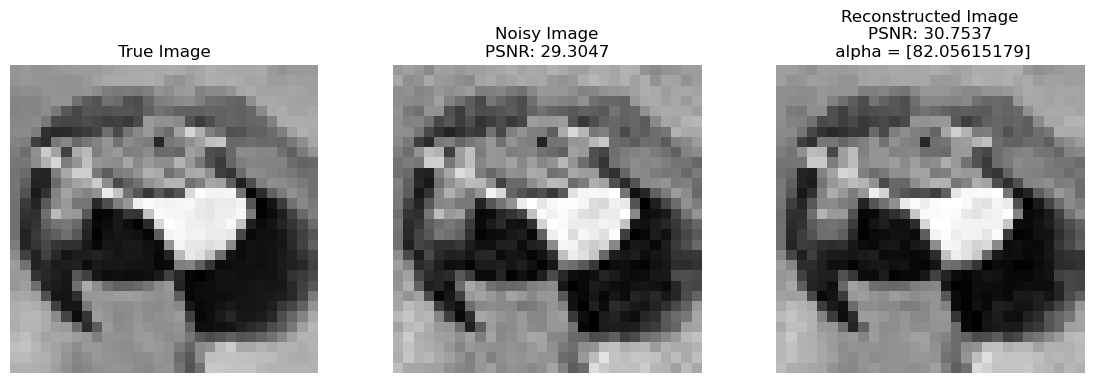

In [21]:
u_mpcc_scaled = u_mpcc.reshape((scale,scale))
plot_experiment(true,noisy,u_mpcc_scaled,alpha_mpcc)